In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

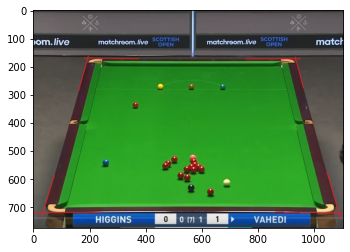

In [23]:
# source_img = cv2.imread("C:\\Users\\86994\\Desktop\\35.jpg") # 读入图片
source_img = cv2.imread("C:\\Users\\86994\\Desktop\\32.png") # 读入图片
plt.imshow(cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB))
plt.show()

In [24]:
dst_width,dst_height  = 204, 382
# dst_width,dst_height  = 250, 350

In [25]:
# 获取仿射变换矩阵
src_points = np.array([[195,169],[933,173],[1087,720],[34,720]], dtype=np.float32) # 台球桌
# src_points = np.array([[533,495],[1345,492],[1556,1650],[397,1696]], dtype=np.float32) # 扑克牌

dst_points = np.array([[0,0],[dst_width,0],[dst_width,dst_height],[0,dst_height]], dtype=np.float32)

expand_factor = 3 # 扩充倍数，使有足够的空间包含变换后的像素，并将变换结果置于中央
dst_points = dst_points + np.array([dst_width/2*(expand_factor-1),dst_height/2*(expand_factor-1)], dtype=np.float32)


M = cv2.getPerspectiveTransform(src_points, dst_points)
h, mask = cv2.findHomography( src_points,dst_points,method=cv2.RANSAC) # 就是单应性矩阵

In [26]:
dst_img = cv2.warpPerspective(source_img, M, [dst_width*expand_factor, dst_height*expand_factor])

In [27]:
cv2.imwrite("C:\\Users\\86994\\Desktop\\32_output.jpg", dst_img)

True

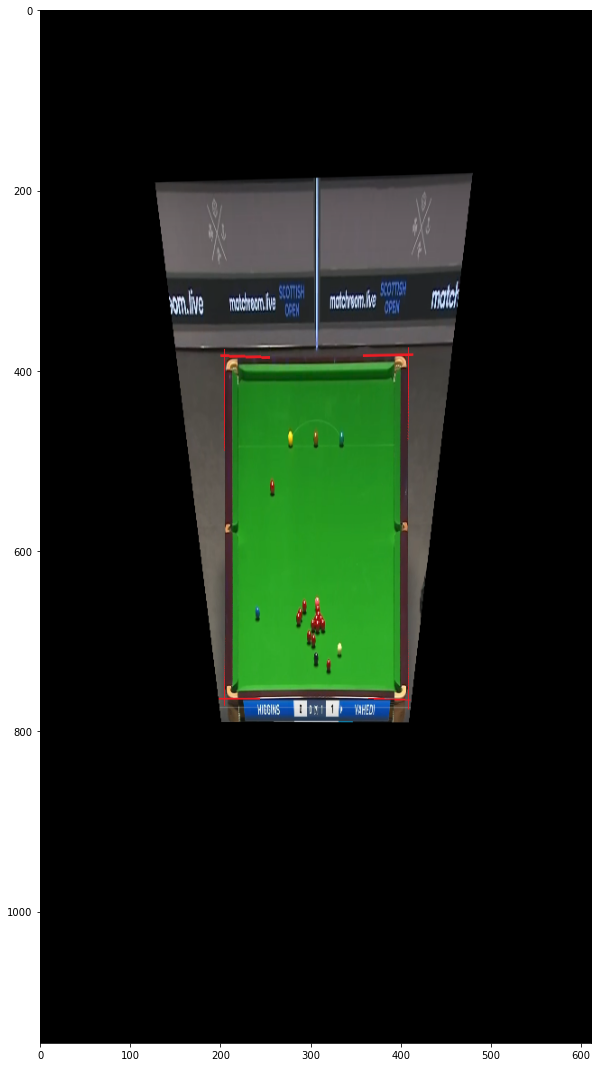

In [28]:
plt.figure(figsize=(10, 19))
plt.imshow(cv2.cvtColor(dst_img, cv2.COLOR_BGR2RGB))
plt.show()